In [1]:
from scipy.io import mmread
from scipy.sparse import csr_matrix
import anndata as ad
import pandas as pd
import scvi
import numpy as np
import scanpy as sc
scvi.settings.seed = 420
import os, sys, time, gc
from os.path import join

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/setuptools_scm/_integration/setuptools.py:30: RuntimeWarning: 
ERROR: setuptools==59.5.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(
Global seed set to 0
Global seed set to 420


In [2]:
data_dir = '../../../data/processed/Misar-Stereo'

ad_mis13_rna = sc.read_h5ad(join(data_dir, 'Misar-E13/ad_rna.h5ad'))
ad_mis13_atac = sc.read_h5ad(join(data_dir, 'Misar-E13/ad_atac.h5ad'))

ad_mis15_rna = sc.read_h5ad(join(data_dir, 'Misar-E15/ad_rna.h5ad'))
ad_mis15_atac = sc.read_h5ad(join(data_dir, 'Misar-E15/ad_atac.h5ad'))

ad_mis18_rna = sc.read_h5ad(join(data_dir, 'Misar-E18/ad_rna.h5ad'))
ad_mis18_atac = sc.read_h5ad(join(data_dir, 'Misar-E18/ad_atac.h5ad'))

ad_ste12_rna = sc.read_h5ad(join(data_dir, 'Stereo-E12/ad_rna.h5ad'))
ad_ste14_rna = sc.read_h5ad(join(data_dir, 'Stereo-E14/ad_rna.h5ad')) 
ad_ste16_rna = sc.read_h5ad(join(data_dir, 'Stereo-E16/ad_rna.h5ad')) 

In [3]:
ad_rna_all = sc.concat([ad_mis13_rna, ad_mis15_rna, ad_mis18_rna, ad_ste12_rna, ad_ste14_rna, ad_ste16_rna])

sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Sample')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

ad_atac_all = sc.concat([ad_mis13_atac, ad_mis15_atac, ad_mis18_atac])

# ac.pp.tfidf(ad_atac_all, scale_factor=1e4)
sc.pp.highly_variable_genes(ad_atac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Sample')
hvp_names = ad_atac_all.var.query('highly_variable').index.to_numpy()

In [4]:
ad_mis13_rna = ad_mis13_rna[:, hvg_names].copy()
ad_mis15_rna = ad_mis15_rna[:, hvg_names].copy()
ad_mis18_rna = ad_mis18_rna[:, hvg_names].copy()

ad_ste12_rna = ad_ste12_rna[:, hvg_names].copy()
ad_ste14_rna = ad_ste14_rna[:, hvg_names].copy()
ad_ste16_rna = ad_ste16_rna[:, hvg_names].copy()

ad_mis13_atac = ad_mis13_atac[:, hvp_names].copy()
ad_mis15_atac = ad_mis15_atac[:, hvp_names].copy()
ad_mis18_atac = ad_mis18_atac[:, hvp_names].copy()

In [5]:
for adx in [ad_mis13_rna, ad_mis15_rna, ad_mis18_rna, ad_ste12_rna, ad_ste14_rna, ad_ste16_rna]:
    adx.var['modality'] = ['Gene Expression']*adx.shape[1]
for adx in [ad_mis13_atac, ad_mis15_atac, ad_mis18_atac]:
    adx.var['modality'] = ['Peaks']*adx.shape[1]

In [6]:
def colcat(ads):
    adx = sc.concat(ads, axis=1)
    adx.obs = ads[0].obs.copy()
    return adx

def rowcat(ads):
    adx = sc.concat(ads)
    adx.var = ads[0].var.copy()
    return adx

In [7]:
ad_mis13 = colcat([ad_mis13_rna, ad_mis13_atac])
ad_mis15 = colcat([ad_mis15_rna, ad_mis15_atac])
ad_mis18 = colcat([ad_mis18_rna, ad_mis18_atac])

In [8]:
ad_mis = rowcat([ad_mis13, ad_mis15, ad_mis18])
ad_ste = rowcat([ad_ste12_rna, ad_ste14_rna, ad_ste16_rna])
ad_mis.obs['modality'] = 'paired'
ad_ste.obs['modality'] = 'geneExpr'

/tmp/ipykernel_32121/1974270550.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ad_ste.obs['modality'] = 'geneExpr'


In [9]:
# We can now use the organizing method from scvi to concatenate these anndata
adata_mvi = scvi.data.organize_multiome_anndatas(multi_anndata=ad_mis, 
                                                 rna_anndata=ad_ste,
                                                 atac_anndata=None)

print(adata_mvi.shape)

adata_mvi = adata_mvi[:, adata_mvi.var["modality"].argsort()].copy()
scvi.model.MULTIVI.setup_anndata(adata_mvi, batch_key="modality", categorical_covariate_keys=['Sample'])

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


(50334, 110000)


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [10]:
model = scvi.model.MULTIVI(
    adata_mvi,
    n_genes=(adata_mvi.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata_mvi.var["modality"] == "Peaks").sum(),
)
model.view_anndata_setup()

model.train()

latent = model.get_latent_representation()

# np.savetxt(arguments[3]+"/MultiVI.csv", latent, delimiter=',')

Anndata setup with scvi-tools version 0.15.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'modality',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['Sample'],
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_cells          │ 50334  │
│          n_vars          │ 110000 │
│         n_batch          │   2    │
│         n_labels         │   1    │
│ n_extra_categorical_covs │   1    │
│ n_extra_continuous_covs  │   0    │
└──────────────────────────┴────────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│         labels         │         adata.obs['_scvi_labels']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
└────────────────────────┴────────────────────────────────────────────┘

...

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │  E13_5-S1  │          0          │
│                     │  E15_5-S1  │          1          │
│                     │  E18_5-S1  │          2          │
│                     │ stereo-E12 │          3          │
│                     │ stereo-E14 │          4          │
│                     │ stereo-E16 │          5          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/500:   0%|                                                                                                                                                                        | 0/500 [00:00<?, ?it/s]

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scvi/module/_multivae.py:567: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2981.)
  x = torch.where(mask_expr.T, x_expr.T, x_acc.T).T


Epoch 196/500:  39%|██████████████████████████████████████████████████▏                                                                             | 196/500 [2:17:53<3:33:52, 42.21s/it, loss=2.48e+03, v_num=1]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 5222.779. Signaling Trainer to stop.


In [11]:
adata_mvi

AnnData object with n_obs × n_vars = 50334 × 110000
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'mclust_8', 'mclust_12', 'mclust_16', 'louvain_0.1', 'louvain_0.5', 'louvain_1.0', 'modality', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - Alx1', 'Regulon - Alx4', 'Regulon - Arid3a', 'Regulon - Arx', 'Regulon - Atf1', 'Regulon - Atf2', 'Regulon - Atf4', 'Regulon - Barhl1', 'Regulon - Bclaf1', 'Regulon - Bmyc', 'Regulon - Brca1', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Cdx1', 'Regulon - Cdx2', 'Regulon - Cebpa', 'Regulon - Cebpe', 'Regulon - Creb1', 'Regulon - Creb3l1',

In [12]:
adata_mvi.obsm['emb'] = latent.copy()
sc.pp.neighbors(adata_mvi, use_rep='emb', n_neighbors=15)
sc.tl.umap(adata_mvi)

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


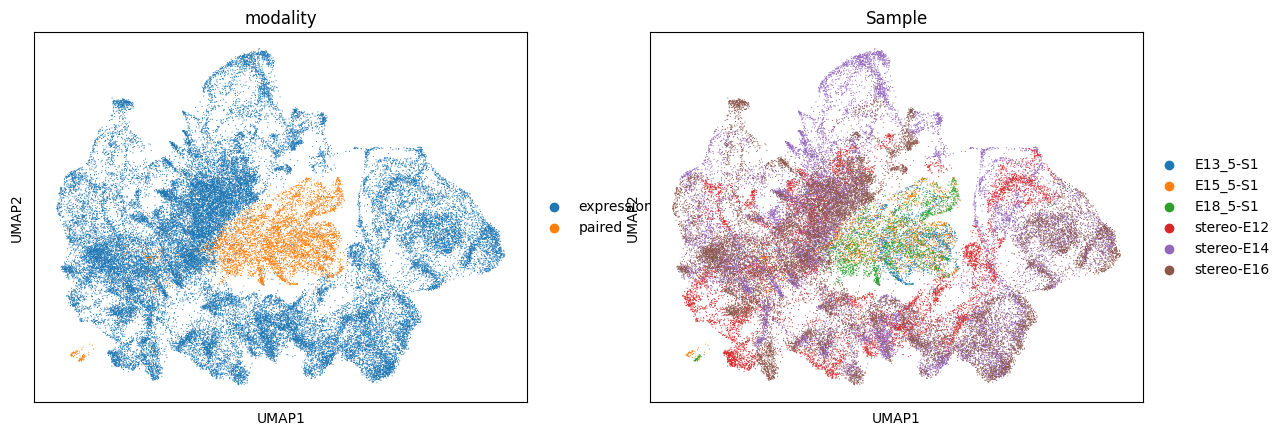

In [13]:
sc.pl.umap(adata_mvi, color=['modality', 'Sample'])

In [14]:
anal_dir = f'../../../results/embeddings/MultiVI/Misar-Stereo'
os.makedirs(anal_dir, exist_ok=True)

df = pd.DataFrame(latent, index=[x.rsplit('_', 1)[0] for x in adata_mvi.obs_names])
df.to_csv(join(anal_dir, 'df_emb.csv'))